In [1]:
from src.utils.config_loader import load_config
from src.utils.data_loader import DataLoader
from src.transform.feature_engineering import FeatureEngineer
from src.training.tuner import Tuner
from src.training.trainer import Trainer
from src.evaluate.metrics import rmse

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec 
from xgboost import XGBRegressor


/Users/mickail.khadhar/Documents/Projets Perso/Actuarial_Loss/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load Data 

paths = load_config("config/paths.yaml")
schema = load_config("config/schema.yaml")
model_config = load_config("config/model.yaml")
loader = DataLoader(paths)

train = loader.load_train()
test = loader.load_test()



2026-06-03 12:09:13.132 | INFO     | src.utils.data_loader:_load:35 - Loading 'train' from data/train.csv
2026-06-03 12:09:13.244 | INFO     | src.utils.data_loader:_load:37 - Loaded 'train': shape=(54000, 15)
2026-06-03 12:09:13.245 | INFO     | src.utils.data_loader:_load:35 - Loading 'test' from data/test.csv
2026-06-03 12:09:13.298 | INFO     | src.utils.data_loader:_load:37 - Loaded 'test': shape=(36000, 14)


In [ ]:
train = FeatureEngineer.extract_datetime_features(train)
train = FeatureEngineer.extract_claim_keywords(train)
train = FeatureEngineer.drop_text_columns(train)
train = FeatureEngineer.encode_categoricals(train)
train = FeatureEngineer.add_wage_to_initial_ratio(train)
train = FeatureEngineer.add_off_hours_flag(train)
train = FeatureEngineer.drop_low_signal_features(train)

test = FeatureEngineer.extract_datetime_features(test)
test = FeatureEngineer.extract_claim_keywords(test)
test = FeatureEngineer.drop_text_columns(test)
test = FeatureEngineer.encode_categoricals(test)
test = FeatureEngineer.add_wage_to_initial_ratio(test)
test = FeatureEngineer.add_off_hours_flag(test)
test = FeatureEngineer.drop_low_signal_features(test)

features = schema["features"]["numerical"] + schema["features"]["categorical"]
target = schema["target_column"]


2026-06-03 12:09:17.130 | INFO     | src.transform.feature_engineering:extract_datetime_features:30 - Datetime features extracted
2026-06-03 12:09:17.134 | INFO     | src.transform.feature_engineering:drop_text_columns:46 - Dropped text columns: ['ClaimDescription']
2026-06-03 12:09:17.140 | INFO     | src.transform.feature_engineering:encode_categoricals:68 - Categorical columns encoded
2026-06-03 12:09:17.143 | INFO     | src.transform.feature_engineering:add_wage_to_initial_ratio:88 - Feature wage_to_initial_ratio added
2026-06-03 12:09:17.146 | INFO     | src.transform.feature_engineering:drop_low_signal_features:122 - Dropped low-signal features: ['report_month', 'accident_month', 'accident_dayofweek', 'accident_hour', 'Gender', 'MaritalStatus', 'DependentsOther', 'DaysWorkedPerWeek']
2026-06-03 12:09:17.211 | INFO     | src.transform.feature_engineering:extract_datetime_features:30 - Datetime features extracted
2026-06-03 12:09:17.214 | INFO     | src.transform.feature_engineerin

In [4]:
X = train[features]
y = train[target]
cat_cols = schema["features"]["categorical"]
X[cat_cols] = X[cat_cols].astype("category")

tuner = Tuner(model_config)
best_params = tuner.tune(X, y)
trials_report = tuner.trials_report()

2026-06-03 12:09:20.835 | INFO     | src.training.tuner:tune:80 - Starting tuning — 120 trials, 5-fold CV
2026-06-03 12:30:34.545 | INFO     | src.training.tuner:tune:87 - Best RMSE: 27710.7185 | Params: {'n_estimators': 753, 'learning_rate': 0.007599354010643751, 'max_depth': 4, 'subsample': 0.8014269872607886, 'colsample_bytree': 0.8769384644620178, 'min_child_weight': 3, 'reg_alpha': 2.330623941341836, 'reg_lambda': 0.19647225658099332, 'tweedie_variance_power': 1.3822114922726174, 'gamma': 0.4527160254920978, 'colsample_bylevel': 0.9506479510859867, 'max_delta_step': 4.261940608726345}


In [ ]:
best_params = model_config["xgboost"] | best_params

In [5]:
model = Trainer(model_config).fit(X, y, extra_params=best_params)
preds = model.predict(X)
print(f"Train RMSE: {rmse(y.to_numpy(), preds):.2f}")

2026-06-02 23:10:54.652 | INFO     | src.training.trainer:fit:29 - Model fitted — 54000 rows, 6 features


Train RMSE: 28366.00


In [ ]:
#Nth model tuned 
model = Trainer(model_config).fit(X, y, extra_params=best_params)
preds = model.predict(X)
print(f"Train RMSE: {rmse(y.to_numpy(), preds):.2f}")

2026-06-03 12:30:35.845 | INFO     | src.training.trainer:fit:29 - Model fitted — 54000 rows, 8 features


Train RMSE: 28855.96


In [6]:
# -- Create Submission File ─────────────────────────────────────────────

X_test = test[features]
X_test[cat_cols] = X_test[cat_cols].astype("category")
test_preds = model.predict(X_test)

submission = pd.DataFrame({
    schema["id_column"]: test[schema["id_column"]],
    schema["target_column"]: test_preds,
})

print(submission.head())
print(f"Shape: {submission.shape}")
submission.to_csv("data/submission_v3.csv", index=False)

  ClaimNumber  UltimateIncurredClaimCost
0   WC8145235               10596.631836
1   WC2005111                4450.179199
2   WC6899143               39040.738281
3   WC5502023                 818.291504
4   WC4785156                7742.236328
Shape: (36000, 2)


The Following code displays first the Shap Values/ Feature importance for the last model tried. 

After this, it displays the Shap Values/ Feature importance for the first model tried in order to have baseline to compare with the last model. 



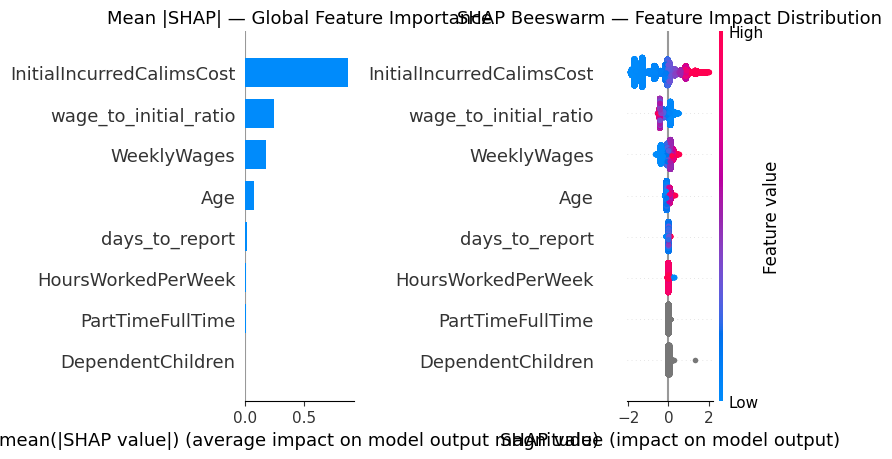

In [ ]:
# ── Nth Model SHAP — Global Explainability ─────────────────────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
plt.sca(axes[0])
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
axes[0].set_title("Mean |SHAP| — Global Feature Importance", fontsize=13)
plt.sca(axes[1])
shap.summary_plot(shap_values, X, show=False)
axes[1].set_title("SHAP Beeswarm — Feature Impact Distribution", fontsize=13)
plt.tight_layout()
plt.show()

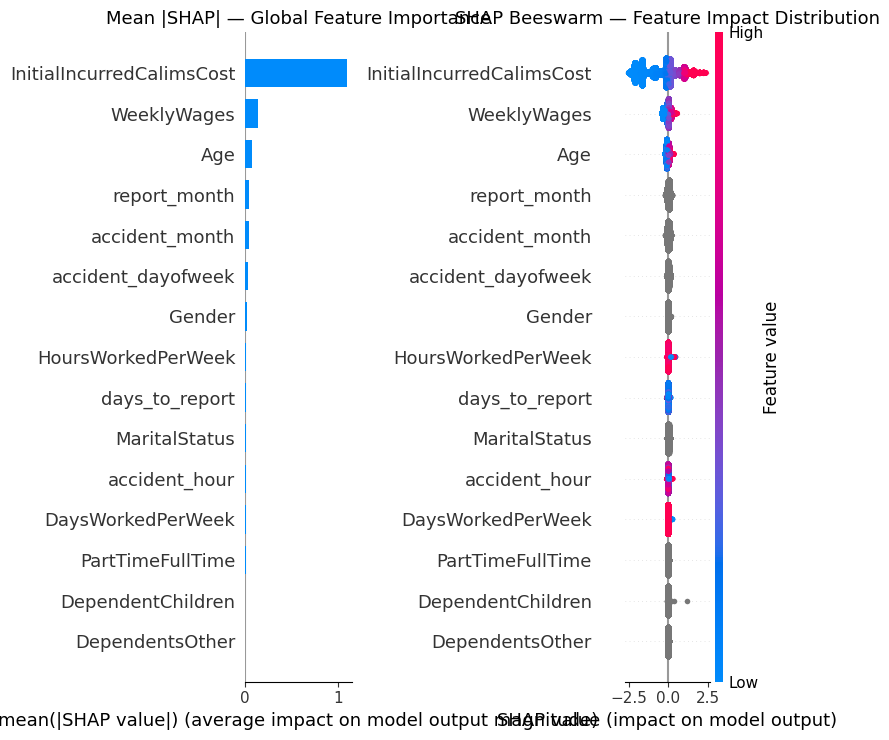

In [8]:
# ── SHAP — Global Explainability ─────────────────────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
axes[0].set_title("Mean |SHAP| — Global Feature Importance", fontsize=13)
plt.sca(axes[1])
shap.summary_plot(shap_values, X, show=False)
axes[1].set_title("SHAP Beeswarm — Feature Impact Distribution", fontsize=13)
plt.tight_layout()
plt.show()

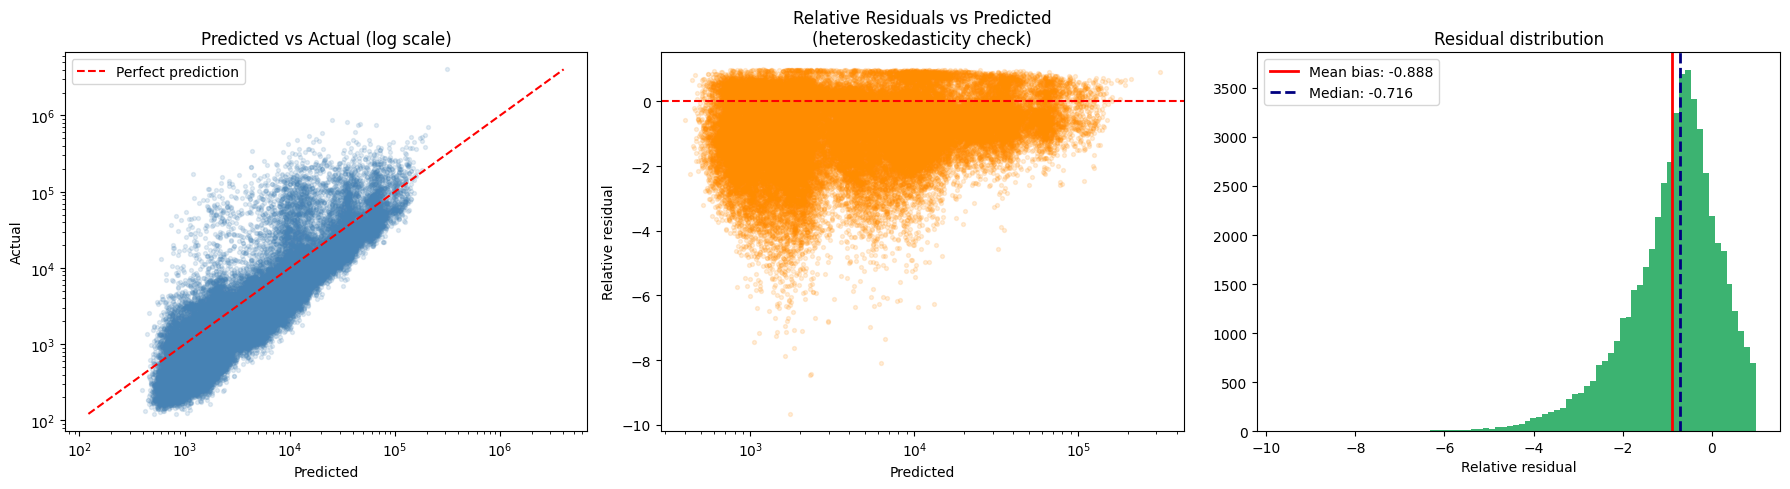

In [9]:
# ── Residual Analysis ─────────────────────────────────────────────────────────
residuals     = y.to_numpy() - preds
rel_residuals = residuals / np.maximum(y.to_numpy(), 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(preds, y, alpha=0.15, s=8, color="steelblue")
lims = [min(preds.min(), float(y.min())), max(preds.max(), float(y.max()))]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Predicted vs Actual (log scale)"); axes[0].legend()

axes[1].scatter(preds, rel_residuals, alpha=0.15, s=8, color="darkorange")
axes[1].axhline(0, color="red", lw=1.5, linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Relative residual")
axes[1].set_title("Relative Residuals vs Predicted\n(heteroskedasticity check)")

axes[2].hist(rel_residuals, bins=80, color="mediumseagreen", edgecolor="none")
axes[2].axvline(np.mean(rel_residuals), color="red", lw=2, label=f"Mean bias: {np.mean(rel_residuals):.3f}")
axes[2].axvline(np.median(rel_residuals), color="navy", lw=2, linestyle="--", label=f"Median: {np.median(rel_residuals):.3f}")
axes[2].set_xlabel("Relative residual"); axes[2].set_title("Residual distribution")
axes[2].legend()
plt.tight_layout(); plt.show()

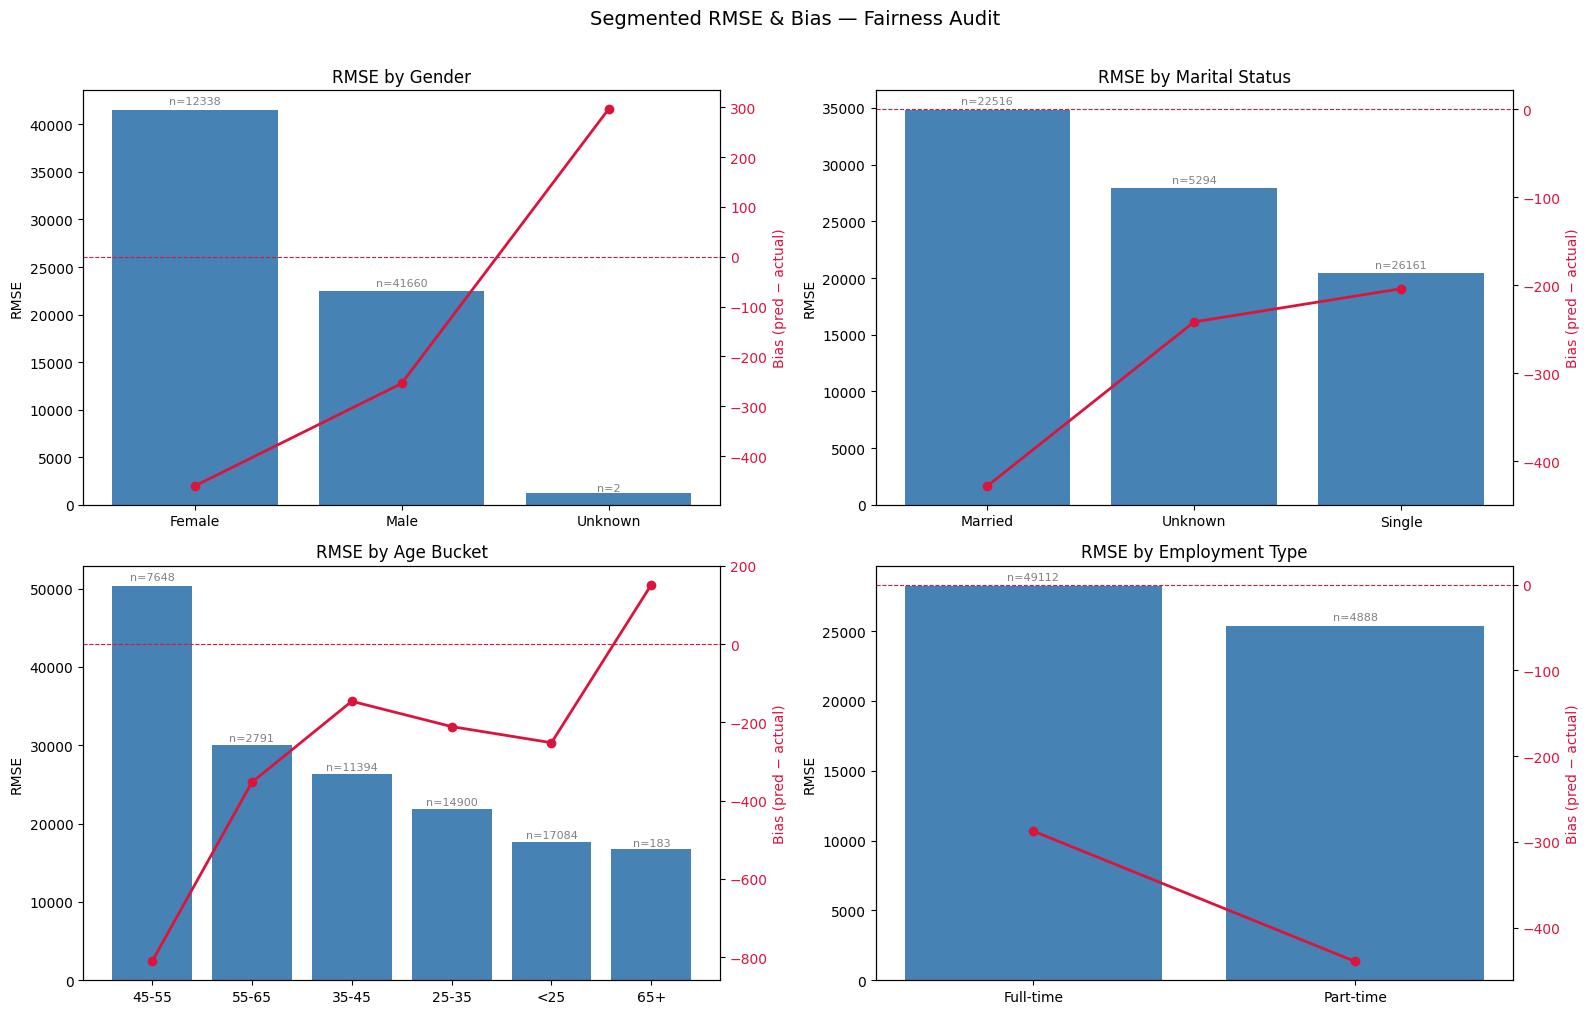


── Gender ──


,Gender_label,n,RMSE,MeanRelErr,Bias,MeanActual,MeanPred
0,Female,12338.0,41500.11,0.95,-459.88,12877.58,12417.69
1,Male,41660.0,22521.12,1.06,-254.16,10448.54,10194.38
2,Unknown,2.0,1189.28,0.22,296.13,6086.34,6382.47



── Marital Status ──


,Marital_label,n,RMSE,MeanRelErr,Bias,MeanActual,MeanPred
0,Married,22516.0,34812.42,1.06,-428.05,12024.93,11596.89
2,Unknown,5294.0,27937.92,0.95,-241.64,16067.82,15826.18
1,Single,26161.0,20466.39,1.03,-204.01,9105.58,8901.57



── Age Bucket ──


,AgeBucket,n,RMSE,MeanRelErr,Bias,MeanActual,MeanPred
3,45-55,7648.0,50392.06,1.02,-810.90,15644.09,14833.19
4,55-65,2791.0,30026.25,1.04,-352.94,16900.92,16547.98
2,35-45,11394.0,26377.36,1.05,-145.94,13287.31,13141.37
1,25-35,14900.0,21868.81,1.03,-210.59,10135.05,9924.46
0,<25,17084.0,17674.86,1.04,-251.82,7137.10,6885.28
5,65+,183.0,16766.91,0.91,152.12,16543.00,16695.12



── Part/Full Time ──


,PT_label,n,RMSE,MeanRelErr,Bias,MeanActual,MeanPred
0,Full-time,49112.0,28261.80,1.04,-287.39,10769.87,10482.48
1,Part-time,4888.0,25393.84,0.94,-439.34,13349.44,12910.09


In [12]:
# ── Segmented RMSE & Bias — Fairness Audit ───────────────────────────────────
analysis_df = X.copy()
analysis_df["y_true"] = y.to_numpy()
analysis_df["y_pred"] = preds
analysis_df["abs_err"] = np.abs(analysis_df["y_true"] - analysis_df["y_pred"])
analysis_df["rel_err"] = analysis_df["abs_err"] / np.maximum(analysis_df["y_true"], 1)

def segmented_metrics(df: pd.DataFrame, col: str) -> pd.DataFrame:
    def _agg(g):
        return pd.Series({
            "n":          len(g),
            "RMSE":       np.sqrt(np.mean((g["y_true"] - g["y_pred"]) ** 2)),
            "MeanRelErr": g["rel_err"].mean(),
            "Bias":       (g["y_pred"] - g["y_true"]).mean(),
            "MeanActual": g["y_true"].mean(),
            "MeanPred":   g["y_pred"].mean(),
        })
    return df.groupby(col).apply(_agg).reset_index().sort_values("RMSE", ascending=False)

analysis_df["Gender_label"]  = analysis_df["Gender"].astype(str).map({"0": "Male", "1": "Female", "2": "Unknown"})
analysis_df["Marital_label"] = analysis_df["MaritalStatus"].astype(str).map({"0": "Single", "1": "Married", "2": "Unknown"})
analysis_df["PT_label"]      = analysis_df["PartTimeFullTime"].astype(str).map({"0": "Part-time", "1": "Full-time"})
analysis_df["AgeBucket"]     = pd.cut(analysis_df["Age"], bins=[0, 25, 35, 45, 55, 65, 200],
                                       labels=["<25", "25-35", "35-45", "45-55", "55-65", "65+"])

gender_seg  = segmented_metrics(analysis_df, "Gender_label")
marital_seg = segmented_metrics(analysis_df, "Marital_label")
pt_seg      = segmented_metrics(analysis_df, "PT_label")
age_seg     = segmented_metrics(analysis_df, "AgeBucket")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (seg_df, col, title) in zip(axes.flatten(), [
    (gender_seg,  "Gender_label",  "RMSE by Gender"),
    (marital_seg, "Marital_label", "RMSE by Marital Status"),
    (age_seg,     "AgeBucket",     "RMSE by Age Bucket"),
    (pt_seg,      "PT_label",      "RMSE by Employment Type"),
]):
    bars = ax.bar(seg_df[col].astype(str), seg_df["RMSE"], color="steelblue", edgecolor="none")
    ax2  = ax.twinx()
    ax2.plot(seg_df[col].astype(str), seg_df["Bias"], color="crimson", marker="o", lw=2, label="Bias")
    ax2.axhline(0, color="crimson", lw=0.8, linestyle="--")
    ax2.set_ylabel("Bias (pred − actual)", color="crimson")
    ax2.tick_params(axis="y", labelcolor="crimson")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("RMSE")
    for bar, n in zip(bars, seg_df["n"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"n={int(n)}", ha="center", va="bottom", fontsize=8, color="gray")
plt.suptitle("Segmented RMSE & Bias — Fairness Audit", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print("\n── Gender ──");        display(gender_seg.round(2))
print("\n── Marital Status ──"); display(marital_seg.round(2))
print("\n── Age Bucket ──");     display(age_seg.round(2))
print("\n── Part/Full Time ──"); display(pt_seg.round(2))

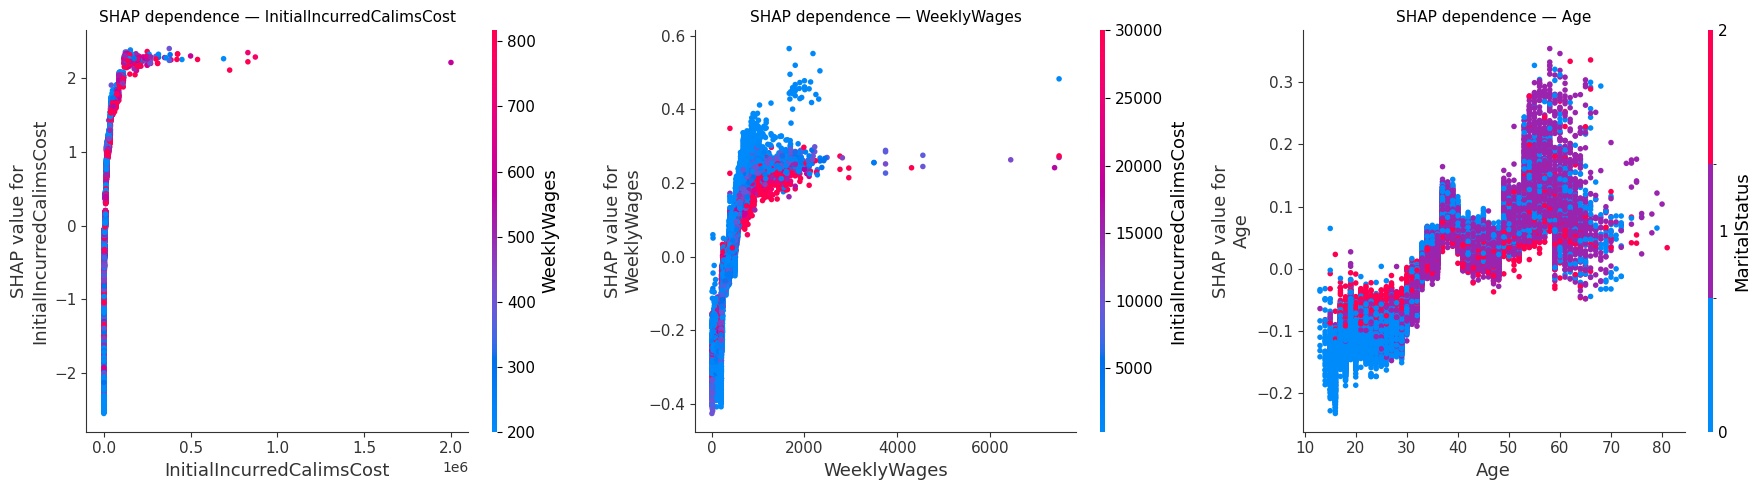

In [13]:
# ── SHAP Dependence Plots — Top 3 Features ───────────────────────────────────
top3 = (
    pd.DataFrame({"feature": X.columns, "mean_shap": np.abs(shap_values.values).mean(axis=0)})
    .nlargest(3, "mean_shap")["feature"]
    .tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_values.values, X, ax=ax, show=False)
    ax.set_title(f"SHAP dependence — {feat}", fontsize=11)
plt.tight_layout(); plt.show()

In [14]:
import pandas as pd
import numpy as np

diag = analysis_df.copy()
diag["Gender_label"] = diag["Gender"].astype(str).map({"0": "Male", "1": "Female", "2": "Unknown"})

# Is InitialIncurredCalimsCost itself biased by gender?
print(diag.groupby("Gender_label")[["InitialIncurredCalimsCost", "WeeklyWages", "y_true"]].median().round(0))

# Are large losses driving the gap?
diag["is_large"] = diag["y_true"] > diag["y_true"].quantile(0.95)
print("\nLarge loss rate by gender:")
print(diag.groupby("Gender_label")["is_large"].mean().round(3))

# RMSE split: large vs attritional, by gender
for gender in ["Male", "Female"]:
    for large in [True, False]:
        subset = diag[(diag["Gender_label"] == gender) & (diag["is_large"] == large)]
        if len(subset) > 0:
            r = np.sqrt(np.mean((subset["y_true"] - subset["y_pred"]) ** 2))
            print(f"{gender} | {'Large' if large else 'Attritional'} | n={len(subset)} | RMSE={r:,.0f}")

              InitialIncurredCalimsCost  WeeklyWages  y_true
Gender_label                                                
Female                           3500.0        344.0  4487.0
Male                             2000.0        408.0  3044.0
Unknown                          4100.0        417.0  6086.0

Large loss rate by gender:
Gender_label
Female     0.059
Male       0.047
Unknown    0.000
Name: is_large, dtype: float64
Male | Large | n=1975 | RMSE=99,144
Male | Attritional | n=39685 | RMSE=6,577
Female | Large | n=725 | RMSE=168,452
Female | Attritional | n=11613 | RMSE=7,632
